
Copyright (C) 2024 - 2026 Synopsys, Inc. and ANSYS, Inc. All rights reserved.
SPDX-License-Identifier: Apache-2.0


Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at

    http://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software
distributed under the License is distributed on an "AS IS" BASIS,
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
See the License for the specific language governing permissions and
limitations under the License.

In [1]:
from pathlib import Path
import shutil
import sys
import tempfile
import time

In [2]:
from ansys.aedt.toolkits.radar_explorer.backend.api import ToolkitBackend
from ansys.aedt.toolkits.radar_explorer.rcs_visualization import MonostaticRCSData
from ansys.aedt.toolkits.radar_explorer.rcs_visualization import MonostaticRCSPlotter

## Set AEDT version

In [3]:
aedt_version = "2026.1"

## Set non-graphical mode

In [4]:
non_graphical = True

## Set number of cores

In [5]:
cores = 4

## Create temporary directory

In [6]:
temp_dir = tempfile.TemporaryDirectory(suffix="_ansys")

## Get example project

In [7]:
car_original = r"example_models\geometries\car_stl.stl"
car = Path(temp_dir.name) / "car.stl"
shutil.copy(car_original, car)

WindowsPath('C:/Users/ansys/AppData/Local/Temp/tmphnflirht_ansys/car.stl')

## Initialize toolkit

In [8]:
toolkit_api = ToolkitBackend()

## Get toolkit properties

In [9]:
properties_from_backend = toolkit_api.get_properties()

## Set properties

Set non-graphical mode.

In [10]:
set_properties = {"non_graphical": non_graphical, "aedt_version": aedt_version}
flag_set_properties, msg_set_properties = toolkit_api.set_properties(set_properties)

INFO - Updating internal properties.


## Initialize AEDT

Launch a new AEDT session in a thread.

In [11]:
thread_msg = toolkit_api.launch_thread(toolkit_api.launch_aedt)

PyAEDT INFO: Python version 3.14.5 (tags/v3.14.5:5607950, May 10 2026, 10:43:50) [MSC v.1944 64 bit (AMD64)].


PyAEDT INFO: PyAEDT version 1.8.0.


PyAEDT INFO: Initializing new Desktop session.


## Wait for the toolkit thread to be idle

Wait for the toolkit thread to be idle and ready to accept a new task.

In [12]:
idle = toolkit_api.wait_to_be_idle()
if not idle:
    print("AEDT not initialized.")
    sys.exit()

PyAEDT INFO: New AEDT session is starting on gRPC port 57519.


PyAEDT INFO: Starting new AEDT gRPC session on port 57519.


PyAEDT INFO: Launching AEDT server with gRPC transport mode: TransportMode.WNUA


PyAEDT INFO: Electronics Desktop started on gRPC port 57519 after 11.6 seconds.


PyAEDT INFO: AEDT installation Path C:\Program Files\ANSYS Inc\v261\AnsysEM


PyAEDT INFO: 2026.1 version started with process ID 2544.


PyAEDT INFO: Non-graphical mode detected. Disabling Desktop logs.


PyAEDT INFO: Desktop has been released.


INFO - AEDT is released.


## Connect design

Connect an existing design or create a new design.

In [13]:
toolkit_api.connect_design("HFSS")

PyAEDT INFO: Python version 3.14.5 (tags/v3.14.5:5607950, May 10 2026, 10:43:50) [MSC v.1944 64 bit (AMD64)].


PyAEDT INFO: PyAEDT version 1.8.0.


PyAEDT INFO: Initializing Desktop session.


PyAEDT INFO: AEDT version 2026.1.


PyAEDT INFO: Port 57519 session has been found.


...

PyAEDT INFO: Project Project2 Saved correctly


PyAEDT INFO: Active Design set to HFSS_LB5LK2


INFO - Updating internal properties.


INFO - Toolkit is connected to AEDT design.


True

## Import CAD

In [14]:
toolkit_api.properties.cad.input_file = [car]
toolkit_api.properties.cad.material = ["pec"]
toolkit_api.properties.cad.position = [[0.0, 0.0, 0.0]]

## Set calculation type

In [15]:
new_properties = {"calculation_type": "2D ISAR"}

In [16]:
flag3, msg3 = toolkit_api.set_properties(new_properties)

INFO - Updating internal properties.


In [17]:
new_properties = {"ray_density": 0.1, "ffl": True, "num_cores": cores}
flag4, msg4 = toolkit_api.set_properties(new_properties)

INFO - Updating internal properties.


## Set ISAR 2D properties

In [18]:
new_properties = {
    "range_max_az": 14.3,
    "range_res_az": 0.15,
    "range_max": 15.0,
    "range_res": 0.15,
    "sim_freq_lower": 9.5e9,
    "sim_freq_upper": 10.5e9,
}
flag5, msg5 = toolkit_api.set_properties(new_properties)

INFO - Updating internal properties.


In [19]:
properties1 = toolkit_api.get_properties()

C:\actions-runner\_work\ansys-aedt-toolkits-radar-explorer\ansys-aedt-toolkits-radar-explorer\.venv\Lib\site-packages\pydantic\main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `str` - serialized value may not be as expected [field_name='input_file', input_value=WindowsPath('C:/Users/ans...hnflirht_ansys/car.stl'), input_type=WindowsPath])
  return self.__pydantic_serializer__.to_python(


In [20]:
toolkit_api.update_isar_2d_properties(range_is_system=False, azimuth_is_system=False)

Check how ``aspect_ang_phi`` and ``num_phi`` has changed.

In [21]:
properties2 = toolkit_api.get_properties()

## Connect design and load project information

In [22]:
toolkit_api.launch_aedt()

True

## Insert CAD

In [23]:
toolkit_api.insert_cad_sbr()

PyAEDT INFO: Desktop has been released.


INFO - AEDT is released.


PyAEDT INFO: Python version 3.14.5 (tags/v3.14.5:5607950, May 10 2026, 10:43:50) [MSC v.1944 64 bit (AMD64)].


PyAEDT INFO: PyAEDT version 1.8.0.


PyAEDT INFO: Initializing Desktop session.


...

PyAEDT INFO: Active Design set to HFSS_LB5LK2_XBQM1V


INFO - Updating internal properties.


PyAEDT INFO: Desktop has been released.


INFO - AEDT is released.


'HFSS_LB5LK2_XBQM1V'

## Assign excitation

In [24]:
v_plane_wave = toolkit_api.add_plane_wave(name="IncWaveVpol", polarization="Vertical")

PyAEDT INFO: Python version 3.14.5 (tags/v3.14.5:5607950, May 10 2026, 10:43:50) [MSC v.1944 64 bit (AMD64)].


PyAEDT INFO: PyAEDT version 1.8.0.


PyAEDT INFO: Initializing Desktop session.


PyAEDT INFO: AEDT version 2026.1.


PyAEDT INFO: Port 57519 session has been found.


...

PyAEDT INFO: Modeler class has been initialized! Elapsed time: 0m 0sec


PyAEDT INFO: Boundary Plane Incident Wave IncWaveVpol has been created.


INFO - Plane wave IncWaveVpol created.


PyAEDT INFO: Desktop has been released.


INFO - AEDT is released.


## Create setup

In [25]:
setup_name = toolkit_api.add_setup()

PyAEDT INFO: Python version 3.14.5 (tags/v3.14.5:5607950, May 10 2026, 10:43:50) [MSC v.1944 64 bit (AMD64)].


PyAEDT INFO: PyAEDT version 1.8.0.


PyAEDT INFO: Initializing Desktop session.


PyAEDT INFO: AEDT version 2026.1.


PyAEDT INFO: Port 57519 session has been found.


...

PyAEDT INFO: File C:\Users\ansys\AppData\Local\Temp\pytest-of-ansys\pytest-9606\Project2.aedt correctly loaded. Elapsed time: 0m 0sec


PyAEDT INFO: aedt file load time 0.05364727973937988


INFO - Setup rcs_setup created.


PyAEDT INFO: Desktop has been released.


INFO - AEDT is released.


## Get toolkit properties

In [26]:
properties = toolkit_api.get_properties()

## Analyze

In [27]:
toolkit_api.analyze()
toolkit_api.save_project()

PyAEDT INFO: Python version 3.14.5 (tags/v3.14.5:5607950, May 10 2026, 10:43:50) [MSC v.1944 64 bit (AMD64)].


PyAEDT INFO: PyAEDT version 1.8.0.


PyAEDT INFO: Initializing Desktop session.


PyAEDT INFO: AEDT version 2026.1.


PyAEDT INFO: Port 57519 session has been found.


...

PyAEDT INFO: Active Design set to HFSS_LB5LK2_XBQM1V


INFO - Updating internal properties.


PyAEDT INFO: Desktop has been released.


INFO - AEDT is released.


True

## Get RCS data

In [28]:
rcs_metadata_vv = toolkit_api.export_rcs(v_plane_wave, "ComplexMonostaticRCSTheta", encode=False)

PyAEDT INFO: Python version 3.14.5 (tags/v3.14.5:5607950, May 10 2026, 10:43:50) [MSC v.1944 64 bit (AMD64)].


PyAEDT INFO: PyAEDT version 1.8.0.


PyAEDT INFO: Initializing Desktop session.


PyAEDT INFO: AEDT version 2026.1.


PyAEDT INFO: Port 57519 session has been found.


...

PyAEDT INFO: 3D Modeler objects parsed. Elapsed time: 0m 0sec


PyAEDT INFO: Solution Correctly loaded. Elapsed time: 0m 0sec


PyAEDT INFO: Solution Correctly parsed. Elapsed time: 0m 0sec


PyAEDT INFO: Desktop has been released.


INFO - AEDT is released.


## Save and release AEDT

In [29]:
toolkit_api.release_aedt(True, True)

PyAEDT INFO: Python version 3.14.5 (tags/v3.14.5:5607950, May 10 2026, 10:43:50) [MSC v.1944 64 bit (AMD64)].


PyAEDT INFO: PyAEDT version 1.8.0.


PyAEDT INFO: Initializing Desktop session.


PyAEDT INFO: AEDT version 2026.1.


PyAEDT INFO: Port 57519 session has been found.


...

PyAEDT INFO: Connected to AEDT gRPC session on port 57519.


PyAEDT INFO: Non-graphical mode detected. Disabling Desktop logs.


PyAEDT INFO: Desktop has been released and closed.


INFO - AEDT is released.


True

## Load RCS data

In [30]:
rcs_data_vv = MonostaticRCSData(rcs_metadata_vv)

## Load RCS plotter

In [31]:
rcs_data_vv_plotter = MonostaticRCSPlotter(rcs_data_vv)

## Set ISAR 2D

Class: ansys.aedt.core.visualization.plot.matplotlib.ReportPlotter

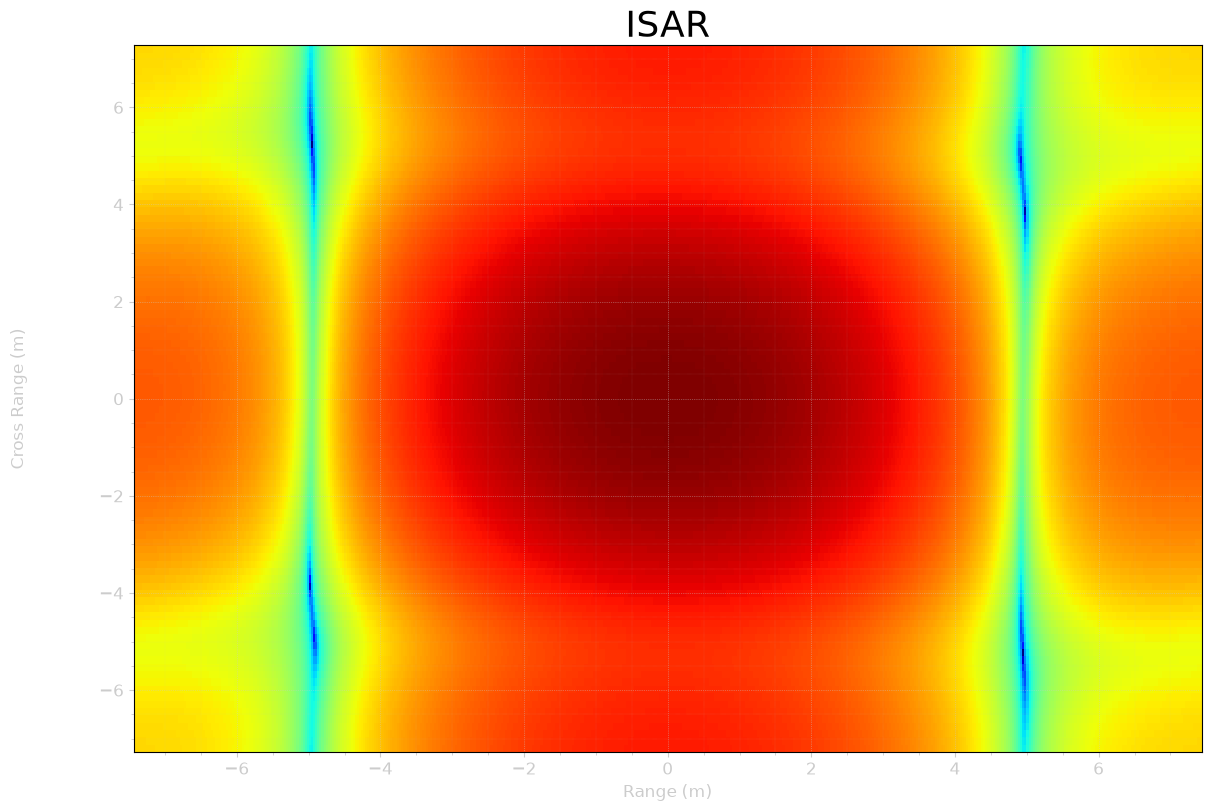

In [32]:
rcs_data_vv_plotter.plot_isar_2d()

## Plot ISAR

In [33]:
rcs_data_vv_plotter.clear_scene()
rcs_data_vv_plotter.add_isar_2d()
rcs_data_vv_plotter.plot_scene()

EmbeddableWidget(value='<iframe srcdoc="<!doctype html>\n<html lang=&quot;en&quot;>\n  <head>\n    <meta chars…

In [34]:
# Wait 3 seconds to allow AEDT to shut down before cleaning the temporary directory.
time.sleep(3)

## Clean temporary directory

In [35]:
temp_dir.cleanup()